--- Null Check ---
Gr Liv Area      0
Lot Area         0
Neighborhood     0
TotRms AbvGrd    0
Year Built       0
SalePrice        0
dtype: int64

--- Descriptive Statistics ---
       Gr Liv Area       Lot Area  TotRms AbvGrd   Year Built      SalePrice
count  2930.000000    2930.000000    2930.000000  2930.000000    2930.000000
mean   1499.690444   10147.921843       6.443003  1971.356314  180796.060068
std     505.508887    7880.017759       1.572964    30.245361   79886.692357
min     334.000000    1300.000000       2.000000  1872.000000   12789.000000
25%    1126.000000    7440.250000       5.000000  1954.000000  129500.000000
50%    1442.000000    9436.500000       6.000000  1973.000000  160000.000000
75%    1742.750000   11555.250000       7.000000  2001.000000  213500.000000
max    5642.000000  215245.000000      15.000000  2010.000000  755000.000000


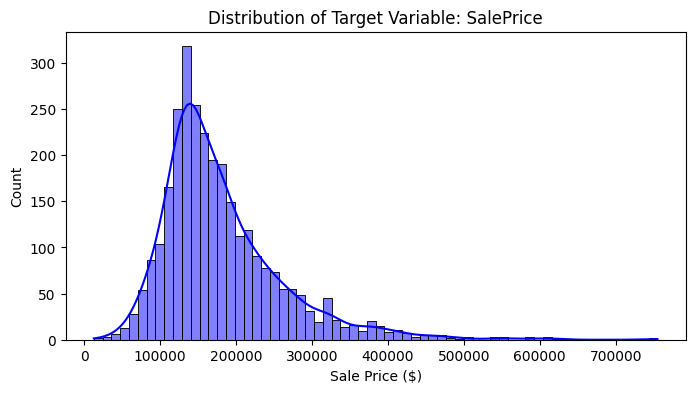

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/OIBSIPDataAnalytics-L1-EDARetailSales/AmesHousing.csv'
df = pd.read_csv(file_path)

# Null check for targeted features
selected_features = ['Gr Liv Area', 'Lot Area', 'Neighborhood', 'TotRms AbvGrd', 'Year Built', 'SalePrice']
print("--- Null Check ---")
print(df[selected_features].isnull().sum())

# Descriptive statistics
print("\n--- Descriptive Statistics ---")
print(df[selected_features].describe())

# Distribution of the target variable (price)
plt.figure(figsize=(8, 4))
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title('Distribution of Target Variable: SalePrice')
plt.xlabel('Sale Price ($)')
plt.show()

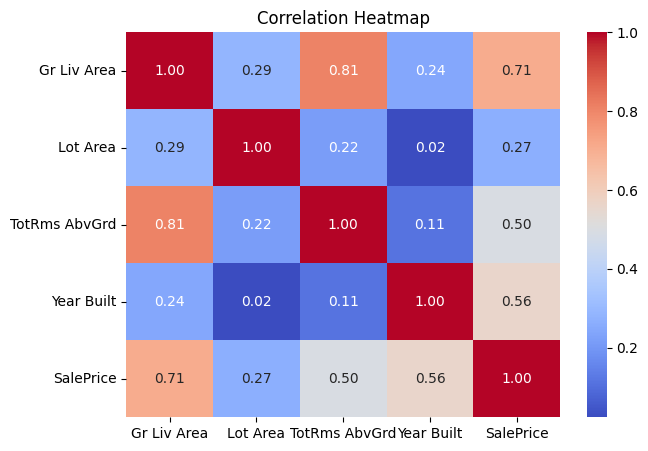

In [4]:
df_filtered = df[selected_features].copy()

# Handle missing values using column medians
for col in df_filtered.select_dtypes(include=[np.number]).columns:
    df_filtered[col] = df_filtered[col].fillna(df_filtered[col].median())

# Encode categorical features (One-Hot Encoding)
df_encoded = pd.get_dummies(df_filtered, columns=['Neighborhood'], drop_first=True)

# Correlation heatmap (Numeric columns vs price)
plt.figure(figsize=(7, 5))
sns.heatmap(df_filtered.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Mean Squared Error (MSE): 1791243942.47
Root Mean Squared Error (RMSE): 42323.09
R² Score: 0.7766



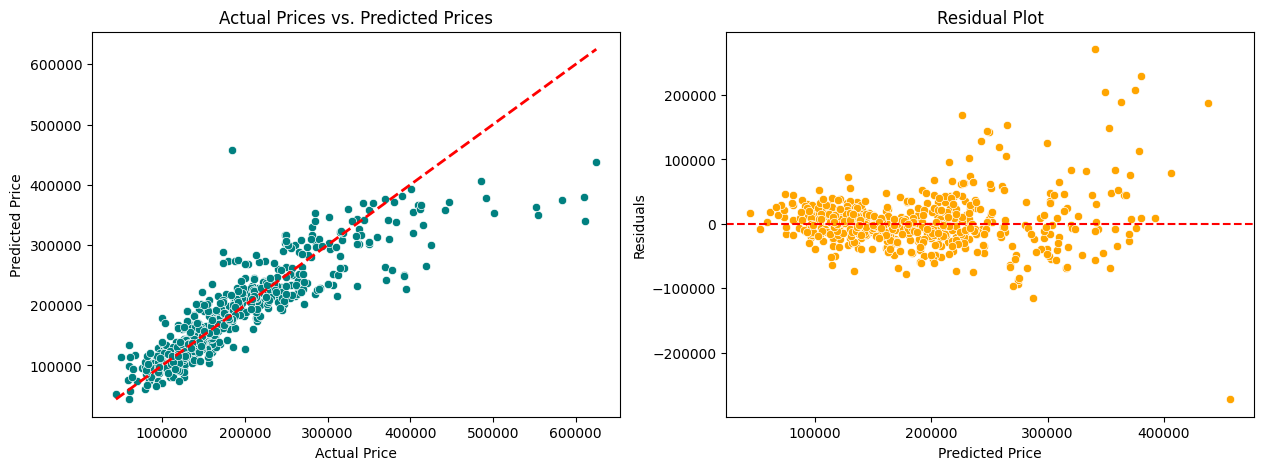

In [5]:
# Train/test split (80/20)
X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}\n")

# Scatter plot: actual prices vs. predicted prices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x=y_test, y=y_pred, ax=ax1, color='teal')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_title('Actual Prices vs. Predicted Prices')
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')

# Residual plot
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, ax=ax2, color='orange')
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_title('Residual Plot')
ax2.set_xlabel('Predicted Price')
ax2.set_ylabel('Residuals')
plt.show()

In [6]:
# Coefficient analysis
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print("--- Highest Positive Impact ---")
print(coefficients.head(3).to_string(index=False))
print("\n--- Highest Negative Impact ---")
print(coefficients.tail(3).to_string(index=False))

# (Bonus) Compare Linear Regression against a Ridge regularised model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
print(f"\nRidge Regularized R² Score: {r2_score(y_test, ridge_pred):.4f}")

--- Highest Positive Impact ---
             Feature  Coefficient
Neighborhood_StoneBr 87130.303213
Neighborhood_GrnHill 85484.491216
Neighborhood_NridgHt 75759.371075

--- Highest Negative Impact ---
             Feature   Coefficient
 Neighborhood_BrDale -40985.556983
Neighborhood_Landmrk -47083.894229
Neighborhood_MeadowV -49301.881102

Ridge Regularized R² Score: 0.7765
